# Perfil de intensidad lineal

In [15]:
# Importamos las librerias necesarias
import cv2
from PIL import Image
from pylab import * 
import numpy as np
import pandas as pd
from skimage.exposure import histogram as imhist
from skimage.color import rgb2gray 
import matplotlib.pyplot as plt
import os

## Analisis para una sola imagen

In [16]:
# Cargamos imagen, se convierte a matriz
image = imread('../DCC1645/L1.png')
# Utilizamos shape para conocer las propiedades de nuestra matriz
print(image.shape)

(1024, 1280, 4)


In [17]:
# Nos aseguramos que la imagen sea un array de NumPy
image = np.array(image)

# Verificamos si la imagen tiene 4 canales
if image.shape[-1] == 4:
    # Elimina el canal alfa
    image = image[..., :3]

In [18]:
# Convertimos la imagen a escala de grises
image = rgb2gray(image)

print(type(image))

# Shape of the image
print("Shape of the image", image.shape)

<class 'numpy.ndarray'>
Shape of the image (1024, 1280)


## Recortamos de manera lineal

In [19]:
linea_pixeles = image[image.shape[0] // 2, :]  # Esto selecciona la fila central

# Convertimos la línea de píxeles en un DataFrame de Pandas
df_linea_pixeles = pd.DataFrame({
    'Pixel': np.arange(len(linea_pixeles)),
    'Intensidad': linea_pixeles
})

# Obtenemos la intensidad máxima y la intensidad promedio de la línea de píxeles
intensidad_maxima = df_linea_pixeles['Intensidad'].max()
intensidad_promedio = df_linea_pixeles['Intensidad'].mean()

print("Intensidad máxima de la línea de píxeles:", intensidad_maxima)
print("Intensidad promedio de la línea de píxeles:", intensidad_promedio)

# Mostramos el DataFrame resultante
print(df_linea_pixeles)

Intensidad máxima de la línea de píxeles: 0.9999999403953552
Intensidad promedio de la línea de píxeles: 0.15565337
      Pixel  Intensidad
0         0    0.018775
1         1    0.021297
2         2    0.021297
3         3    0.021297
4         4    0.021297
...     ...         ...
1275   1275    0.013171
1276   1276    0.013171
1277   1277    0.013171
1278   1278    0.013171
1279   1279    0.013171

[1280 rows x 2 columns]


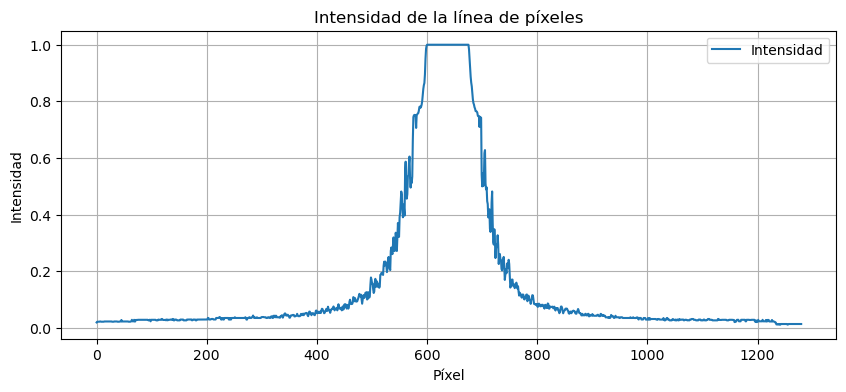

In [20]:
# Graficamos la intensidad de cada pixel en la línea seleccionada
plt.figure(figsize=(10, 4))
plt.plot(df_linea_pixeles['Pixel'], df_linea_pixeles['Intensidad'], label='Intensidad')
plt.xlabel('Píxel')
plt.ylabel('Intensidad')
plt.title('Intensidad de la línea de píxeles')
plt.grid(True)
plt.legend()
plt.show()

## Analisis para todas las imagenes

In [21]:
# Definimos la ruta de la carpeta donde están las imágenes
folder_path = '../DCC1645/'

# Lista de nombres de las imágenes de L1 a L18
image_names = [f'L{i}.png' for i in range(1, 19)]

C:\Users\super\AppData\Local\Temp\ipykernel_28264\780874759.py:42: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  resultados_df = pd.concat([resultados_df, temp_df], ignore_index=True)


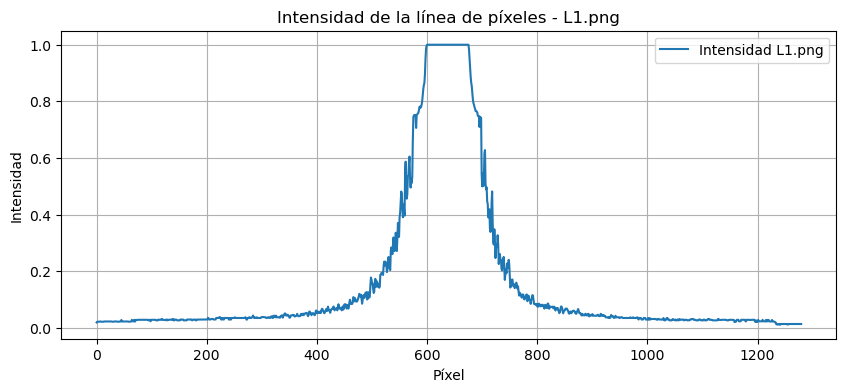

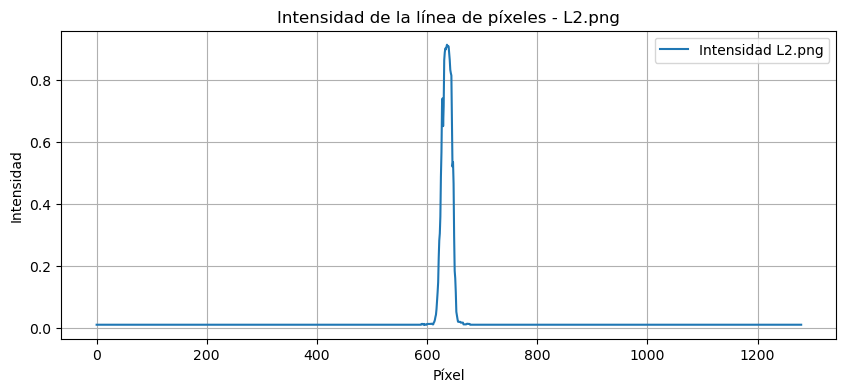

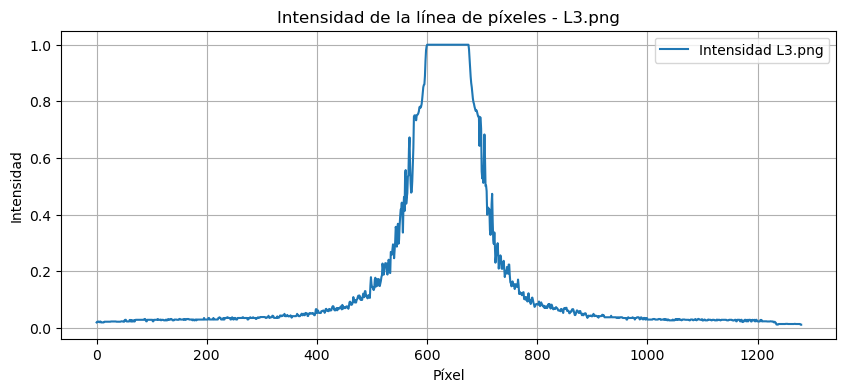

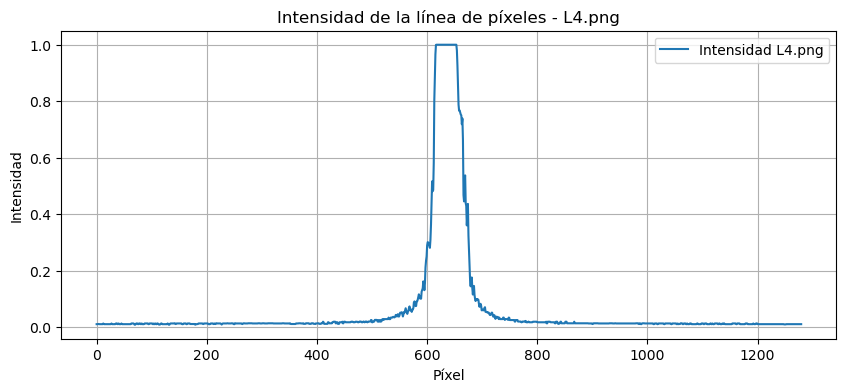

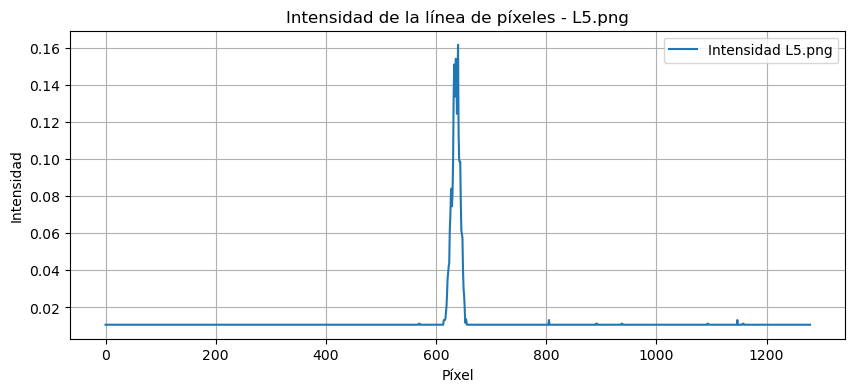

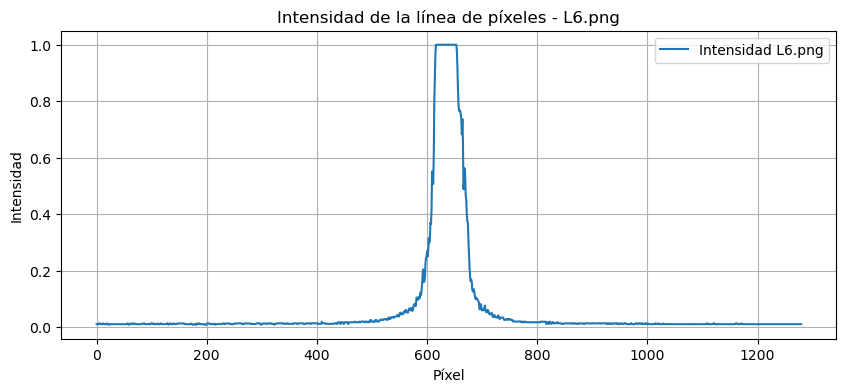

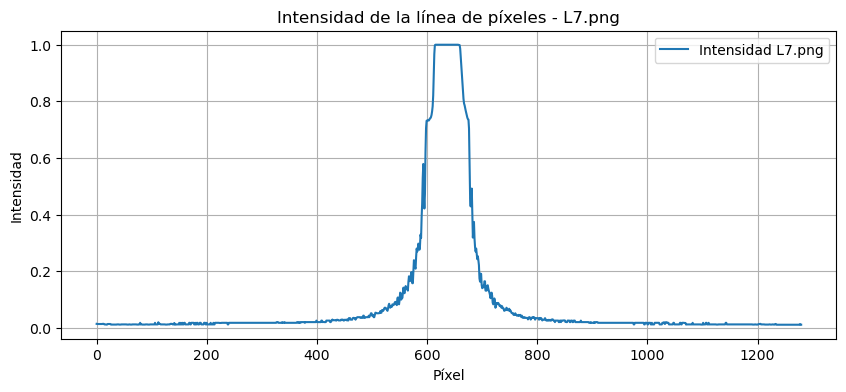

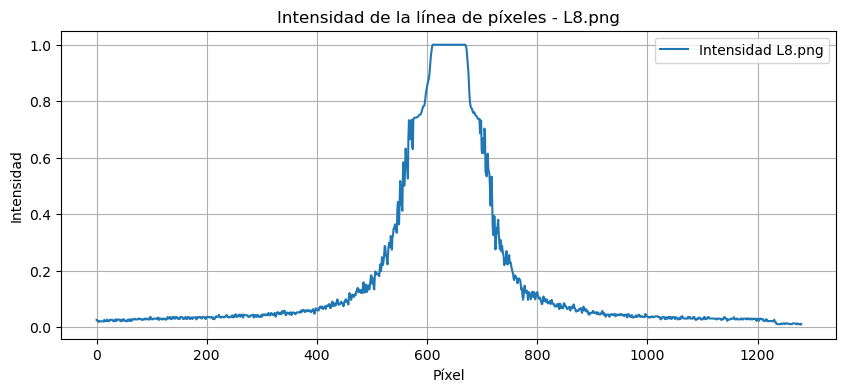

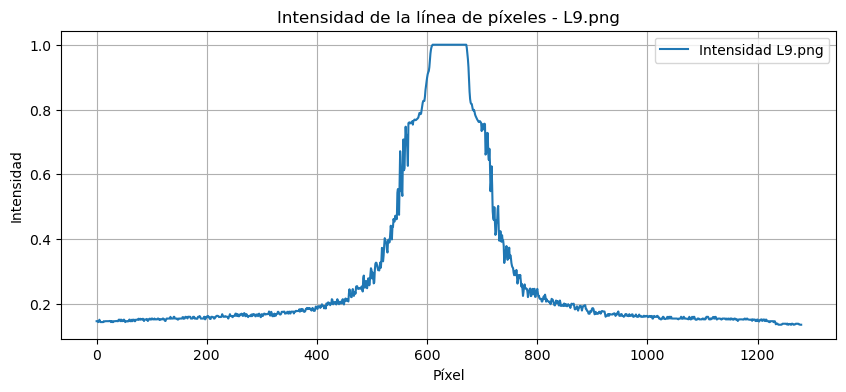

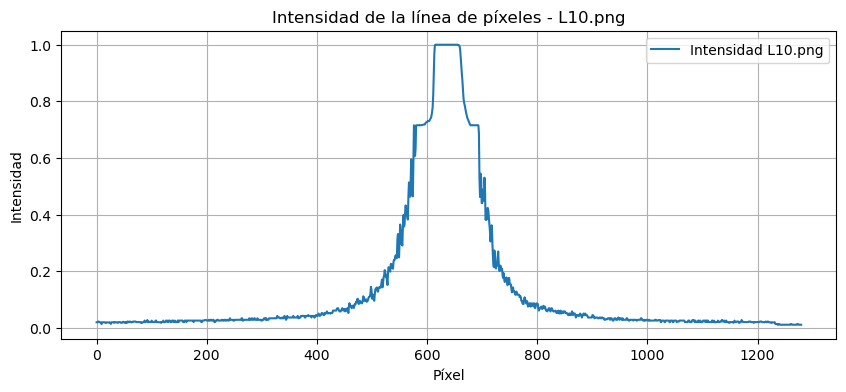

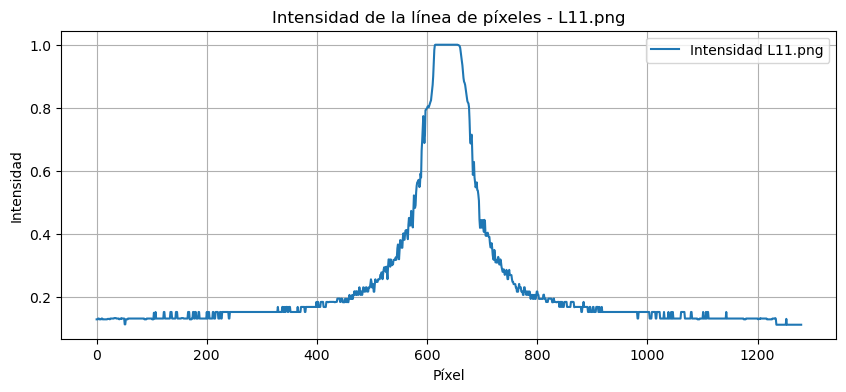

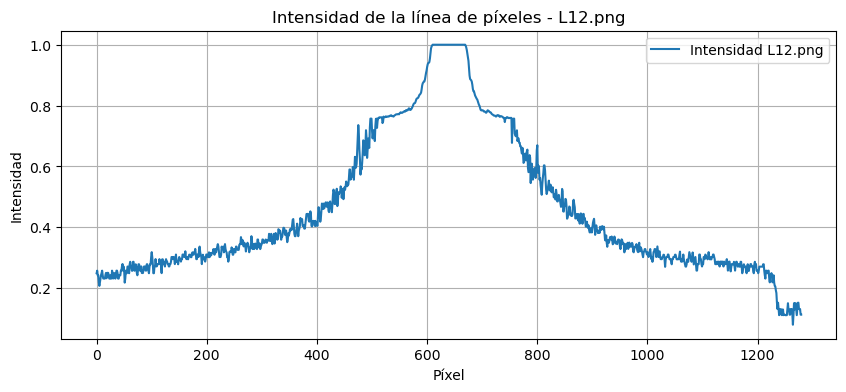

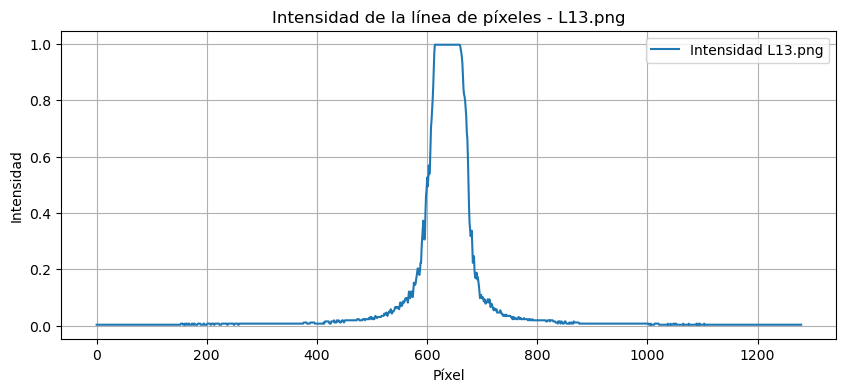

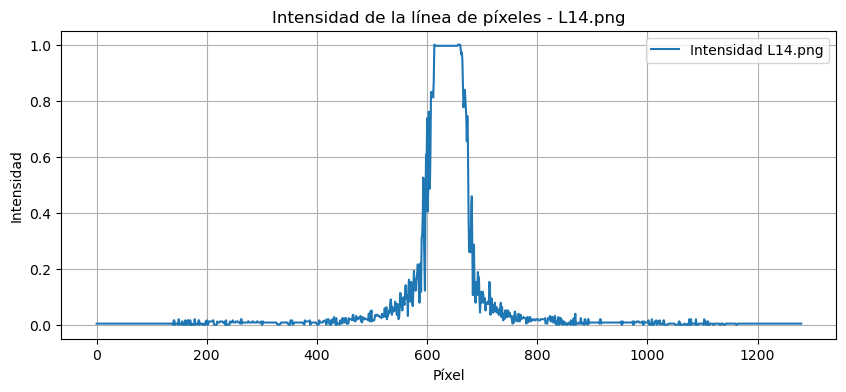

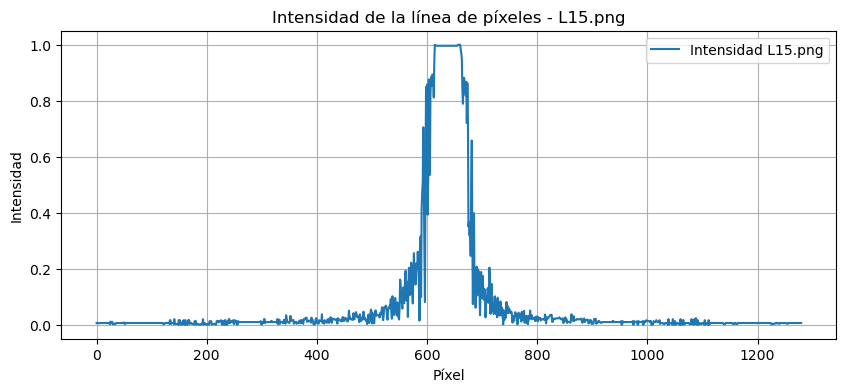

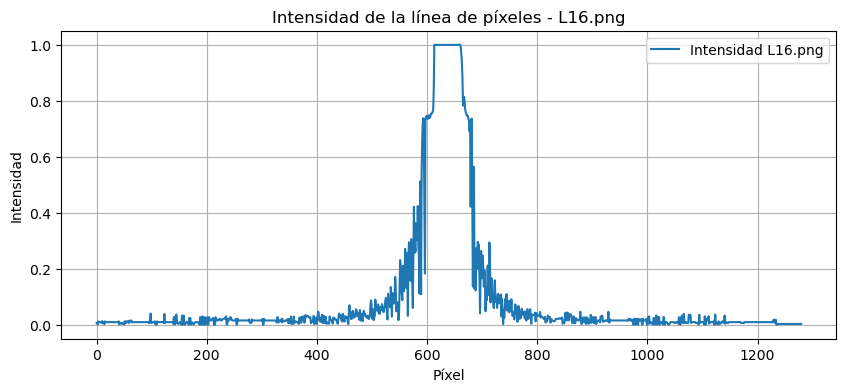

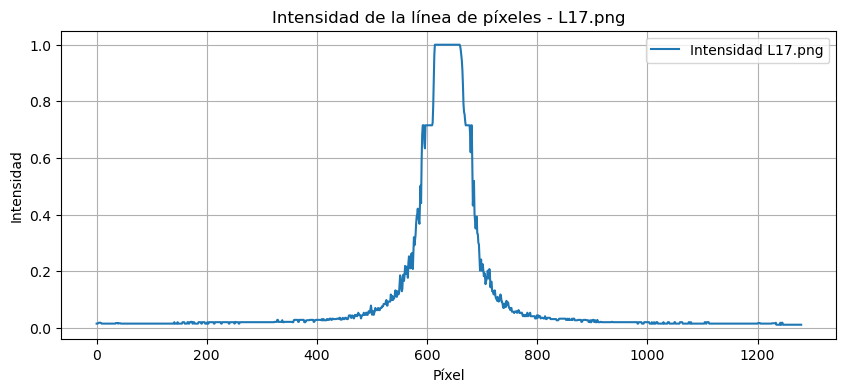

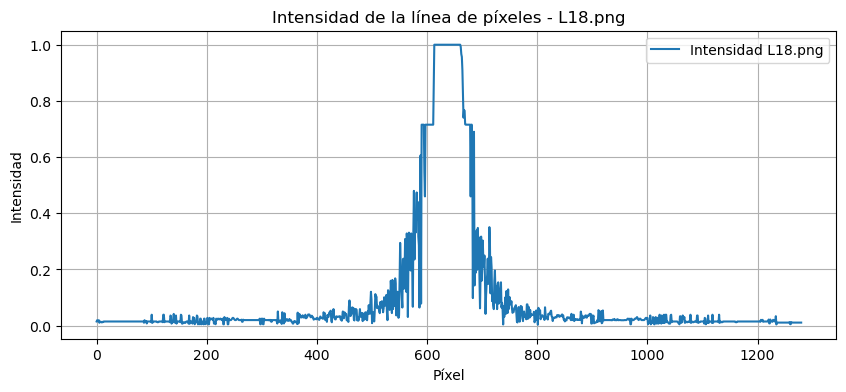

     Imagen  Intensidad Máxima  Intensidad Promedio
0    L1.png           1.000000             0.155653
1    L2.png           0.912336             0.026761
2    L3.png           1.000000             0.154951
3    L4.png           1.000000             0.065652
4    L5.png           0.161778             0.012602
5    L6.png           1.000000             0.065431
6    L7.png           1.000000             0.091821
7    L8.png           1.000000             0.164654
8    L9.png           1.000000             0.276923
9   L10.png           1.000000             0.136144
10  L11.png           1.000000             0.235477
11  L12.png           1.000000             0.455112
12  L13.png           0.996078             0.074923
13  L14.png           1.000000             0.074191
14  L15.png           1.000000             0.081848
15  L16.png           1.000000             0.093795
16  L17.png           1.000000             0.102263
17  L18.png           1.000000             0.100739


In [23]:
# Creamos un DataFrame vacío para almacenar los resultados de cada imagen
resultados_df = pd.DataFrame(columns=['Imagen', 'Intensidad Máxima', 'Intensidad Promedio'])

# Procesamos cada imagen
for image_name in image_names:
    # Cargamos la imagen
    image_path = os.path.join(folder_path, image_name)
    image = imread(image_path)
    
    # Nos aseguramos de que la imagen sea un array de NumPy
    image = np.array(image)
    
    # Verificamos si la imagen tiene 4 canales (RGB + Alfa)
    if image.shape[-1] == 4:
        # Eliminamos el canal alfa
        image = image[..., :3]
    
    # Convertimos la imagen a escala de grises
    image_gray = rgb2gray(image)
    
    # Seleccionamos la línea central de píxeles
    linea_pixeles = image_gray[image_gray.shape[0] // 2, :]
    
    # Creamos un DataFrame con los píxeles y sus intensidades
    df_linea_pixeles = pd.DataFrame({
        'Pixel': np.arange(len(linea_pixeles)),
        'Intensidad': linea_pixeles
    })
    
    # Obtenemos la intensidad máxima y promedio de la línea de píxeles
    intensidad_maxima = df_linea_pixeles['Intensidad'].max()
    intensidad_promedio = df_linea_pixeles['Intensidad'].mean()
    
    # Creamos un DataFrame temporal para almacenar los resultados de la imagen actual
    temp_df = pd.DataFrame({
        'Imagen': [image_name],
        'Intensidad Máxima': [intensidad_maxima],
        'Intensidad Promedio': [intensidad_promedio]
    })
    
    # Concatenamos el DataFrame temporal con el principal
    resultados_df = pd.concat([resultados_df, temp_df], ignore_index=True)
    
    # Graficamos la intensidad de la línea de píxeles para la imagen actual
    plt.figure(figsize=(10, 4))
    plt.plot(df_linea_pixeles['Pixel'], df_linea_pixeles['Intensidad'], label=f'Intensidad {image_name}')
    plt.xlabel('Píxel')
    plt.ylabel('Intensidad')
    plt.title(f'Intensidad de la línea de píxeles - {image_name}')
    plt.grid(True)
    plt.legend()
    plt.show()

# Mostramos el DataFrame con los resultados
print(resultados_df)

# Guardamos los resultados en un archivo CSV
resultados_df.to_csv('resultados_intensidad_imagenes.csv', index=False)
